This notebook implements **YOLOv8** (You Only Look Once - version 8) developed by Ultralytics. The main objective is to train a Quadrant and Enumeration segmentation model (QEM); the workflow includes data preprocessing, model training, and performance evaluation. In addition to the UFBA and DENTEX datasets, we **added Pix2Pix synthetic images** to evaluate performance under different data augmentation scenarios.

# IMPORTS

In [ ]:
import numpy as np 
import pandas as pd
import os

# Import Data Inputs
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
# Import and download datasets
!pip install gdown
!gdown --folder https://drive.google.com/drive/folders/1UabAUSvwcA8Lmep245sM1DMNNJ1deD6T -O ./data/       # Image dataset download
!gdown --folder https://drive.google.com/drive/u/0/folders/1HKCXBZcltonnDdbjtDT6RQD9ZcrGBnyj -O ./        # YOLO trained weights download

# Installing YOLO dependencies
!pip install ultralytics

_____________________________
# DATA PRE-PROCESSING

In [ ]:
import zipfile
from pathlib import Path

DATA_DIR = Path("/kaggle/working/data/YOLOv8")


## ZIP Decompression
zip_paths = {
    "UFBA": DATA_DIR / 'polyUFBA.zip',
    "QE_TRAIN": DATA_DIR / 'QE-TRAIN.zip',
    "QE_VAL": DATA_DIR / 'QE-VAL.zip',
    "PIX2PIX": DATA_DIR / 'pix2pix_gen.zip'
}

print("Starting ZIP decompression...")
for name, path_zip in zip_paths.items():
    if path_zip.exists():
        extract_dir = DATA_DIR
        print(f"Extracting {name} in {extract_dir}...")
        
        with zipfile.ZipFile(path_zip, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)            
        path_zip.unlink()
        
    else:
        print(f"WARNING: zip file not found at {path_zip}")

print("Extraction complete!")

First, we standardize the images and labels to ensure dataset consistency. Since we will be working with a 512x512 px square resolution, we resize the images before training YOLOv8.

In [ ]:
import os
import json
import shutil
import cv2
from collections import defaultdict
from pathlib import Path

def resize_and_save(in_img_dir, in_json_path, out_img_dir, out_json_path, prefix, target_height=512):
    print(f"\nProcessing: {in_img_dir}")
    print(f"Saving in: {out_img_dir}")
    print(f"Applying prefix: '{prefix}' | Resizing to {target_height}px")

    # Creating destination folders
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(os.path.dirname(out_json_path), exist_ok=True)

    # Reading JSON file
    with open(in_json_path, 'r') as f:
        data = json.load(f)

    # Collecting annotations in a dictionary
    annotations_by_image = defaultdict(list)
    for ann in data['annotations']:
        annotations_by_image[ann['image_id']].append(ann)

    processed_count = 0
    resized_count = 0
    copied_count = 0
    missing_count = 0

    # Iterating for JSON images
    for img_info in data['images']:
        old_name = img_info['file_name']
        img_id = img_info['id']

        # renaming files
        if old_name.startswith(prefix):
            new_name = old_name
        else:
            new_name = f"{prefix}{old_name}"

        img_info['file_name'] = new_name          # updating JSON name

        old_path = os.path.join(in_img_dir, old_name)
        new_path = os.path.join(out_img_dir, new_name)

        if not os.path.exists(old_path):
            print(f"    ! Image not found: {old_path}")
            missing_count += 1
            continue

        # DOWNSAMPLING
        img = cv2.imread(old_path)
        if img is None:
            print(f"    ! Can't read image: {old_path}")
            continue

        orig_h, orig_w = img.shape[:2]

        # Check img size
        if orig_h == target_height:
            shutil.copy(old_path, new_path)
            copied_count += 1
            processed_count += 1
            continue

        # Evaluating scale factor
        scale = target_height / float(orig_h)
        new_w = int(orig_w * scale)
        new_h = target_height

        # Resize img and saving
        resized_img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
        cv2.imwrite(new_path, resized_img)
        resized_count += 1
        processed_count += 1

        # JSON UPDATE
        img_info['width'] = new_w
        img_info['height'] = new_h

        # Scaling annotations
        for ann in annotations_by_image.get(img_id, []):
            # Resize BBox [x, y, width, height]
            if 'bbox' in ann:
                ann['bbox'] = [val * scale for val in ann['bbox']]

            # Scale masks (Polygons)
            if 'segmentation' in ann:
                new_segmentation = []
                for polygon in ann['segmentation']:
                    new_polygon = [val * scale for val in polygon]
                    new_segmentation.append(new_polygon)
                ann['segmentation'] = new_segmentation

            # Scale area
            if 'area' in ann:
                ann['area'] = ann['area'] * (scale ** 2)

    # SAVING JSON FILE ON NEW PATH
    with open(out_json_path, 'w') as f:
        json.dump(data, f)

    print(f" -> Number of processed images: {processed_count}")
    if missing_count > 0:
        print(f" -> WARNING: Images found on JSON but not found in the original folder: {missing_count}")


## PATH CONFIG
BASE_DIR = Path("/kaggle/working/data/YOLOv8")

# -- TRAIN QE --
QE_TRAIN_IMG_IN = f'{BASE_DIR}/QE-TRAIN/images'
QE_TRAIN_JSON_IN = f'{BASE_DIR}/QE-TRAIN/train_annotations.json'
QE_TRAIN_IMG_OUT = f'{BASE_DIR}/QE_512-TRAIN/images'
QE_TRAIN_JSON_OUT = f'{BASE_DIR}/QE_512-TRAIN/train_annotations.json'

# -- VALIDATION QE --
QE_VAL_IMG_IN = f'{BASE_DIR}/QE-VAL/images'
QE_VAL_JSON_IN = f'{BASE_DIR}/QE-VAL/labels/test_annotations.json'
QE_VAL_IMG_OUT = f'{BASE_DIR}/QE_512-VAL/images'
QE_VAL_JSON_OUT = f'{BASE_DIR}/QE_512-VAL/labels/test_annotations.json'


## PROCESSING
resize_and_save(QE_TRAIN_IMG_IN, QE_TRAIN_JSON_IN, QE_TRAIN_IMG_OUT, QE_TRAIN_JSON_OUT, "QE_")
resize_and_save(QE_VAL_IMG_IN, QE_VAL_JSON_IN, QE_VAL_IMG_OUT, QE_VAL_JSON_OUT, "QE_")

print("\nResizing complete!")

Next, we convert the JSON annotation files to YOLO-compatible .txt files. During this process, the specific tooth IDs are remapped to class IDs ranging from 0 to 31.

In [ ]:
import os
import json
import shutil
import yaml
from collections import defaultdict
from tqdm import tqdm
from pathlib import Path


## PATH CONFIG
BASE_DIR = Path("/kaggle/working/data/YOLOv8")

# TRAIN
QE_TRAIN_IMG = f'{BASE_DIR}/QE_512-TRAIN/images'
QE_TRAIN_JSON = f'{BASE_DIR}/QE_512-TRAIN/train_annotations.json'

# VALIDATION
QE_VAL_IMG = f'{BASE_DIR}/QE_512-VAL/images'
QE_VAL_JSON = f'{BASE_DIR}/QE_512-VAL/labels/test_annotations.json'

QEM_dataset = '/kaggle/working/QEModel'


# Creating train and val folders
QEM_IMG_TRAIN = os.path.join(QEM_dataset, 'images', 'train')
QEM_IMG_VAL = os.path.join(QEM_dataset, 'images', 'val')
QEM_LBL_TRAIN = os.path.join(QEM_dataset, 'labels', 'train')
QEM_LBL_VAL = os.path.join(QEM_dataset, 'labels', 'val')

os.makedirs(QEM_IMG_TRAIN, exist_ok=True)
os.makedirs(QEM_IMG_VAL, exist_ok=True)
os.makedirs(QEM_LBL_TRAIN, exist_ok=True)
os.makedirs(QEM_LBL_VAL, exist_ok=True)


## CONVERSION FUNCTION
def convert2yolo(json_path, source_img_dir, dest_img_dir, dest_lbl_dir, dataset_name):
    print(f"\nElaborazione dataset {dataset_name}...")

    with open(json_path, 'r') as f:
        data = json.load(f)


    img_info_dict = {img['id']: img for img in data['images']}

    annotations_by_image = defaultdict(list)
    for ann in data['annotations']:
        annotations_by_image[ann['image_id']].append(ann)

    for img_id, img_info in tqdm(img_info_dict.items(), desc=f"Converting {dataset_name}"):
        file_name = img_info['file_name']
        width = img_info['width']
        height = img_info['height']

        src_img_path = os.path.join(source_img_dir, file_name)

        if not os.path.exists(src_img_path):
            continue

        txt_file_name = os.path.splitext(file_name)[0] + '.txt'
        txt_path = os.path.join(dest_lbl_dir, txt_file_name)

        with open(txt_path, 'w') as f_out:
            for ann in annotations_by_image.get(img_id, []):
                # category_id_1: Quadrant (0-3), category_id_2: Enumeration (0-7)
                cat1 = ann['category_id_1']
                cat2 = ann['category_id_2']

                # ID (0-31)
                yolo_class_id = (cat1 * 8) + cat2


                for polygon in ann['segmentation']:
                    norm_polygon = []
                    for i in range(0, len(polygon), 2):
                        x_norm = max(0.0, min(1.0, polygon[i] / width))
                        y_norm = max(0.0, min(1.0, polygon[i+1] / height))
                        norm_polygon.append(f"{x_norm:.6f} {y_norm:.6f}")

                    f_out.write(f"{yolo_class_id} " + " ".join(norm_polygon) + "\n")


        # copy img
        dest_img_path = os.path.join(dest_img_dir, file_name)
        if not os.path.exists(dest_img_path):
            shutil.copy(src_img_path, dest_img_path)


## Processing

# Train
convert2yolo(QE_TRAIN_JSON, QE_TRAIN_IMG, QEM_IMG_TRAIN, QEM_LBL_TRAIN, "QE Train")

# Validation
convert2yolo(QE_VAL_JSON, QE_VAL_IMG, QEM_IMG_VAL, QEM_LBL_VAL, "QE Validation")

print("\nWriting file data.yaml...")

class_names = { (q * 8 + e): f"Q{q}_E{e}" for q in range(4) for e in range(8) }

yaml_data = {
    'train': os.path.join(QEM_dataset, 'images', 'train'),
    'val': os.path.join(QEM_dataset, 'images', 'val'),
    'nc': 32,
    'names': class_names
}


yaml_path = os.path.join(QEM_dataset, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_data, f, default_flow_style=False)

print(f"Dataset and data.yaml pronti in: {QEM_dataset}")

The next cell adds the UFBA dataset processed with SAM where BBox were converted from rectangular to polygonal.

In [ ]:
import os
import shutil
import glob
from tqdm import tqdm


## PATH CONFIG
UFBA_IMG_DIR = "/kaggle/working/data/YOLOv8/polyUFBA/images"
UFBA_LBL_DIR = "/kaggle/working/data/YOLOv8/polyUFBA/labels"

QEM_IMG_TRAIN = "/kaggle/working/QEModel/images/train"
QEM_LBL_TRAIN = "/kaggle/working/QEModel/labels/train"

os.makedirs(QEM_IMG_TRAIN, exist_ok=True)  # check if folders already exist
os.makedirs(QEM_LBL_TRAIN, exist_ok=True)

## DATASET MERGING
print("Merging UFBA with QE Model dataset...")

ufba_labels = glob.glob(os.path.join(UFBA_LBL_DIR, "*.txt"))

for lbl_path in tqdm(ufba_labels, desc="Unione file"):
    base_name = os.path.basename(lbl_path)
    img_name = os.path.splitext(base_name)[0] + ".jpg" # o .png

    src_img_path = os.path.join(UFBA_IMG_DIR, img_name)

    if os.path.exists(src_img_path):

        # New names with prefix "ufba_"
        new_base_name = f"ufba_{base_name}"
        new_img_name = f"ufba_{img_name}"

        dest_lbl_path = os.path.join(QEM_LBL_TRAIN, new_base_name)
        dest_img_path = os.path.join(QEM_IMG_TRAIN, new_img_name)

        # copying label
        if not os.path.exists(dest_lbl_path):
            shutil.copy(lbl_path, dest_lbl_path)

        # copying image
        if not os.path.exists(dest_img_path):
            shutil.copy(src_img_path, dest_img_path)

print(f"\nMerging complete! QEM dataset now contains DENTEX and UFBA.")

-------------------------------
**DATA-AUGMENTATION**
\
This cell adds a specified percentage of synthetic images generated with Pix2Pix. Tests have been carried out by:
* adding +10% of fake images
* adding +50% of fake images
* trainig only on 100% of fake images

In [ ]:
import os
import shutil
import glob
import random
from tqdm import tqdm

## PATH CONFIG
PIX2PIX_IMG_DIR = "/kaggle/working/data/YOLOv8/pix2pix_gen/images" 
PIX2PIX_LBL_DIR = "/kaggle/working/data/YOLOv8/pix2pix_gen/labels" 

QEM_IMG_TRAIN = "/kaggle/working/QEModel/images/train"
QEM_LBL_TRAIN = "/kaggle/working/QEModel/labels/train"

# images to add (eg. 0.2 = 20%, 0.5 = 50%, 1.0 = 100%)
PERCENTAGE_TO_ADD = 0.5
RANDOM_SEED = 42 
IMG_EXT = ".png"

os.makedirs(QEM_IMG_TRAIN, exist_ok=True)
os.makedirs(QEM_LBL_TRAIN, exist_ok=True)

## Merging Dataset
print(f"Preparazione all'aggiunta del {PERCENTAGE_TO_ADD*100}% del dataset Pix2Pix come Data Augmentation...")

all_pix2pix_labels = glob.glob(os.path.join(PIX2PIX_LBL_DIR, "*.txt"))

random.seed(RANDOM_SEED)
random.shuffle(all_pix2pix_labels)

num_to_add = int(len(all_pix2pix_labels) * PERCENTAGE_TO_ADD)
selected_labels = all_pix2pix_labels[:num_to_add]

print(f"{len(all_pix2pix_labels)} Pix2Pix images found. {num_to_add} will be added to YOLOv8 dataset.")

added_count = 0

for lbl_path in tqdm(selected_labels, desc="Integrazione Pix2Pix"):
    base_name = os.path.basename(lbl_path)
    img_name = os.path.splitext(base_name)[0] + IMG_EXT 
    
    src_img_path = os.path.join(PIX2PIX_IMG_DIR, img_name)

    if os.path.exists(src_img_path):
        new_base_name = f"aug_p2p_{base_name}"
        new_img_name = f"aug_p2p_{img_name}"

        dest_lbl_path = os.path.join(QEM_LBL_TRAIN, new_base_name)
        dest_img_path = os.path.join(QEM_IMG_TRAIN, new_img_name)

        if not os.path.exists(dest_lbl_path):
            shutil.copy(lbl_path, dest_lbl_path)

        if not os.path.exists(dest_img_path):
            shutil.copy(src_img_path, dest_img_path)
            
        added_count += 1
    else:
        print(f"\nWARNING: no corresponding image found for label {base_name}")

print(f"\n✅ Data Augmentation completed! {added_count} synthetic images added to YOLO train dataset.")

____________________
# TRAINING

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8m-seg.pt') # selecting Medium model

results = model.train(
    data='/kaggle/working/QEModel/data.yaml',
    epochs=300,          
    imgsz=896,           
    batch=16,            
    workers=4,         
    cache=True,          
    device=[0, 1],
    
    # Training options
    cls=2.5,             # High penalty for classification errors
    lr0=0.0001,          # Very low learning rate
    patience=75,         # Will stop if there are no significant changes within 75 epochs
    cos_lr=True,         # Helps handle small learning rate fluctuations
    dropout=0.15,        

    # Geometric augmentation
    translate=0.1,
    scale=0.5,      
    degrees=10.0,
    fliplr=0.0,          # deactivated to avoid model confusion between left and right side.         
    mosaic=0.0,          
    
    project='GAN_QEM', 
    name='seg_MEDIUM'
)

________________
# RESULTS AND VALIDATION

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Extracting metrics...
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,240,912 parameters, 0 gradients, 104.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3974.3±1187.7 MB/s, size: 791.3 KB)
val: Scanning /kaggle/working/QEModel/labels/val... 180 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 180/180 166.6it/s 1.1s0.0s
val: New cache created: /kaggle/working/QEModel/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 1.3it/s 9.5s0.5s
                   all        18

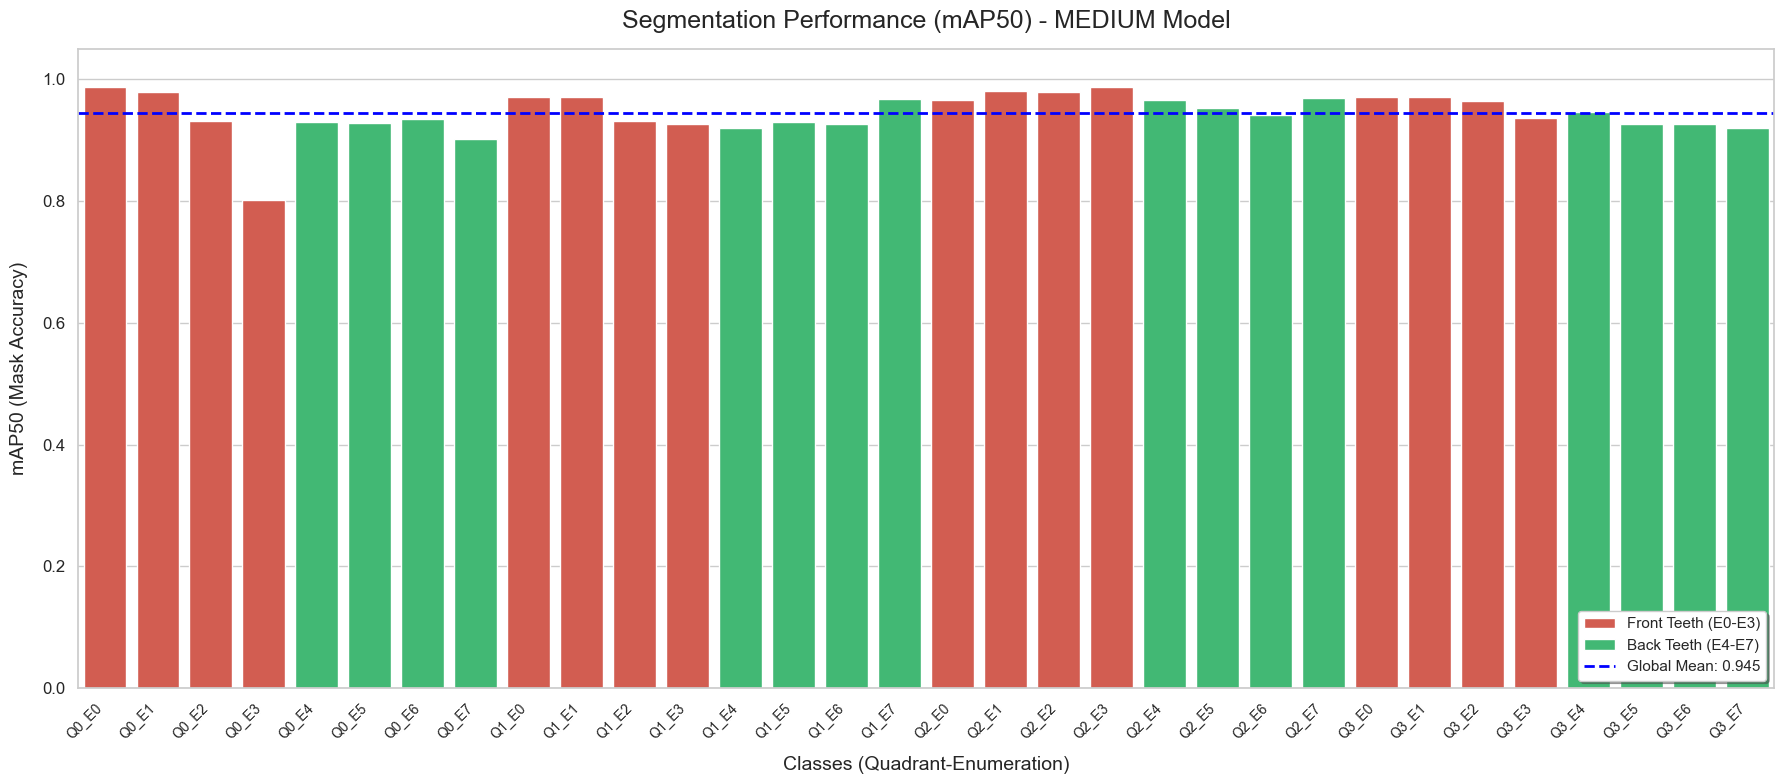

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

# Loading model
model_path = '/kaggle/working/runs/segment/GAN_QEM/seg_MEDIUM/weights/best.pt'
model = YOLO(model_path)

## Starting validation process
print("\nExtracting metrics...")
metrics = model.val(data='/kaggle/working/QEModel/data.yaml', split='val')

# Extracting metrics
class_indices = metrics.seg.ap_class_index
class_names = [metrics.names[i] for i in class_indices]

map50_scores = metrics.seg.ap50
precision_scores = metrics.seg.p  
recall_scores = metrics.seg.r     

df = pd.DataFrame({
    'Classe': class_names,
    'mAP50': map50_scores,
    'mAP50_perc': map50_scores * 100,
    'Precision_perc': precision_scores * 100,
    'Recall_perc': recall_scores * 100
})

def classify_tooth(class_name):
    if any(e in class_name for e in ['E0', 'E1', 'E2', 'E3']):
        return 'Front Teeth (E0-E3)'
    else:
        return 'Back Teeth (E4-E7)'

df['Gruppo'] = df['Classe'].apply(classify_tooth)
df = df.sort_values('Classe')

## DISPLAYING METRICS
print("\n" + "="*65)
print(f"{'CLASS':<12} | {'mAP50':<12} | {'PRECISION':<12} | {'RECALL':<12}")
print("="*65)

for gruppo in df['Gruppo'].unique():
    subset = df[df['Gruppo'] == gruppo]
    media_map = subset['mAP50_perc'].mean()
    media_prec = subset['Precision_perc'].mean()
    media_rec = subset['Recall_perc'].mean()
    
    print(f"\n--- {gruppo.upper()} ---")
    print(f"{'MEAN':<12} | {media_map:>5.1f}%       | {media_prec:>5.1f}%       | {media_rec:>5.1f}%")
    print("-" * 65)
    
    for index, row in subset.iterrows():
        print(f"{row['Classe']:<12} | {row['mAP50_perc']:>5.1f}%       | {row['Precision_perc']:>5.1f}%       | {row['Recall_perc']:>5.1f}%")

print("="*65 + "\n")


plt.figure(figsize=(18, 8))
sns.set_theme(style="whitegrid")

palette = {'Front Teeth (E0-E3)': '#e74c3c', 'Back Teeth (E4-E7)': '#2ecc71'}

ax = sns.barplot(data=df, x='Classe', y='mAP50', hue='Gruppo', dodge=False, palette=palette)

media_globale = df['mAP50'].mean()
plt.axhline(media_globale, color='blue', linestyle='--', linewidth=2, label=f'Global Mean: {media_globale:.3f}')

plt.title('Segmentation Performance (mAP50) - MEDIUM Model', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Classes (Quadrant-Enumeration)', fontsize=14, labelpad=10)
plt.ylabel('mAP50 (Mask Accuracy)', fontsize=14, labelpad=10)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=12)
plt.ylim(0, 1.05)

plt.legend(loc='lower right', frameon=True, shadow=True)
plt.tight_layout() 

plt.savefig('/kaggle/working/precision_comparison.png', dpi=300, bbox_inches='tight') 
print("\nPlot saved in: /kaggle/working/precision_comparison.png")

plt.show()